# 久期计算结果验证分析

本notebook用于验证通过模型计算的基金久期与Wind披露的真实久期之间的差异。

In [11]:
from WindPy import w
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 启动Wind
w.start()
print("Wind连接成功")

Wind连接成功


In [12]:
# 加载计算结果
result_df = pd.read_excel('./output/久期详细结果_exponential_20251231.xlsx')
result_df = result_df.rename(columns={'Unnamed: 0': 'fund_code'})

print(f"总基金数量: {len(result_df)}")
print(f"\n基金类型分布:")
print(result_df['fund_type'].value_counts())
print(f"\n债券类型分布:")
print(result_df['bond_type'].value_counts())

result_df.head()

总基金数量: 1563

基金类型分布:
fund_type
medium_long    1212
short           351
Name: count, dtype: int64

债券类型分布:
bond_type
credit    1212
rate       351
Name: count, dtype: int64


,fund_code,duration,fund_type,bond_type,name
0,000084.OF,1.433921,short,credit,博时安盈A
1,000089.OF,0.881345,short,credit,民生加银高等级信用债C
2,000128.OF,2.362460,short,credit,大成景安短融A
3,000322.OF,1.208187,short,credit,农银汇理金汇A
4,000394.OF,0.218400,short,credit,融通通源短融A


In [13]:
# 批量获取Wind披露的真实久期
def get_wind_duration_batch(fund_codes, rpt_date='20251231', batch_size=100):
    """
    批量获取Wind披露的基金久期
    
    参数:
        fund_codes: 基金代码列表
        rpt_date: 报告日期 'YYYYMMDD'
        batch_size: 每批获取的数量
    
    返回:
        dict: {fund_code: wind_duration}
    """
    wind_durations = {}
    total = len(fund_codes)
    
    for i in range(0, total, batch_size):
        batch = fund_codes[i:i+batch_size]
        print(f"处理进度: {i+1}-{min(i+batch_size, total)}/{total}")
        
        codes_str = ','.join(batch)
        try:
            data = w.wss(codes_str, "risk_durationupdate", f"rptDate={rpt_date}")
            if data.ErrorCode == 0:
                for j, code in enumerate(batch):
                    if j < len(data.Data[0]):
                        value = data.Data[0][j]
                        if value is not None and not (isinstance(value, float) and np.isnan(value)):
                            wind_durations[code] = float(value)
                        else:
                            wind_durations[code] = None
                    else:
                        wind_durations[code] = None
        except Exception as e:
            print(f"批次 {i+1}-{min(i+batch_size, total)} 出错: {e}")
            for code in batch:
                wind_durations[code] = None
    
    return wind_durations

# 获取所有基金的真实久期
fund_codes = result_df['fund_code'].tolist()
wind_durations = get_wind_duration_batch(fund_codes, rpt_date='20251231')

print(f"\n成功获取真实久期的基金数量: {sum(1 for v in wind_durations.values() if v is not None)}")

处理进度: 1-100/1563
处理进度: 101-200/1563
处理进度: 201-300/1563
处理进度: 301-400/1563
处理进度: 401-500/1563
处理进度: 501-600/1563
处理进度: 601-700/1563
处理进度: 701-800/1563
处理进度: 801-900/1563
处理进度: 901-1000/1563
处理进度: 1001-1100/1563
处理进度: 1101-1200/1563
处理进度: 1201-1300/1563
处理进度: 1301-1400/1563
处理进度: 1401-1500/1563
处理进度: 1501-1563/1563

成功获取真实久期的基金数量: 1552


In [14]:
# 合并数据
result_df['wind_duration'] = result_df['fund_code'].map(wind_durations)
result_df['duration_error'] = result_df['duration'] - result_df['wind_duration']
result_df['duration_pct_error'] = (result_df['duration_error'] / result_df['wind_duration']) * 100

# 移除Wind久期为空的记录
valid_df = result_df[result_df['wind_duration'].notna()].copy()

print(f"有效数据数量（有Wind真实久期）: {len(valid_df)}")
print(f"\n按类型统计:")
print(valid_df.groupby(['fund_type', 'bond_type']).size())

valid_df.head()

有效数据数量（有Wind真实久期）: 1552

按类型统计:
fund_type    bond_type
medium_long  credit       879
             rate         324
short        credit       322
             rate          27
dtype: int64


,fund_code,duration,fund_type,bond_type,name,wind_duration,duration_error,duration_pct_error
0,000084.OF,1.433921,short,credit,博时安盈A,0.534242,0.899678,168.402638
1,000089.OF,0.881345,short,credit,民生加银高等级信用债C,0.710841,0.170504,23.986170
2,000128.OF,2.362460,short,credit,大成景安短融A,1.051374,1.311087,124.702280
3,000322.OF,1.208187,short,credit,农银汇理金汇A,0.759769,0.448418,59.020322
4,000394.OF,0.218400,short,credit,融通通源短融A,0.103277,0.115123,111.470635


In [15]:
# 整体误差统计
print("=== 整体误差统计 ===")
print(f"平均绝对误差 (MAE): {valid_df['duration_error'].abs().mean():.4f} 年")
print(f"误差标准差: {valid_df['duration_error'].std():.4f} 年")
print(f"误差中位数: {valid_df['duration_error'].median():.4f} 年")
print(f"\n误差分布:")
print(valid_df['duration_error'].describe())

print(f"\n平均百分比误差: {valid_df['duration_pct_error'].mean():.2f}%")
print(f"百分比误差中位数: {valid_df['duration_pct_error'].median():.2f}%")

=== 整体误差统计 ===
平均绝对误差 (MAE): 1.6621 年
误差标准差: 3.5939 年
误差中位数: 0.3800 年

误差分布:
count    1552.000000
mean        1.211207
std         3.593939
min        -4.281606
25%        -0.176981
50%         0.379956
75%         1.243916
max        35.258088
Name: duration_error, dtype: float64

平均百分比误差: 69.66%
百分比误差中位数: 20.40%


In [16]:
# 按类型分组统计
print("=== 按基金类型和债券类型统计 ===\n")

for fund_type in ['short', 'medium_long']:
    for bond_type in ['credit', 'rate']:
        mask = (valid_df['fund_type'] == fund_type) & (valid_df['bond_type'] == bond_type)
        subset = valid_df[mask]
        
        if len(subset) > 0:
            fund_type_name = '短期' if fund_type == 'short' else '中长期'
            bond_type_name = '信用债' if bond_type == 'credit' else '利率债'
            
            print(f"{fund_type_name}{bond_type_name} (n={len(subset)}):")
            print(f"  平均绝对误差: {subset['duration_error'].abs().mean():.4f} 年")
            print(f"  误差标准差: {subset['duration_error'].std():.4f} 年")
            print(f"  平均计算久期: {subset['duration'].mean():.4f} 年")
            print(f"  平均Wind久期: {subset['wind_duration'].mean():.4f} 年")
            print()

=== 按基金类型和债券类型统计 ===

短期信用债 (n=322):
  平均绝对误差: 0.5586 年
  误差标准差: 0.6871 年
  平均计算久期: 1.4052 年
  平均Wind久期: 1.1253 年

短期利率债 (n=27):
  平均绝对误差: 0.6522 年
  误差标准差: 0.6801 年
  平均计算久期: 1.8371 年
  平均Wind久期: 1.4061 年

中长期信用债 (n=879):
  平均绝对误差: 1.9651 年
  误差标准差: 4.2454 年
  平均计算久期: 3.9019 年
  平均Wind久期: 2.4206 年

中长期利率债 (n=324):
  平均绝对误差: 2.0207 年
  误差标准差: 3.3681 年
  平均计算久期: 5.5491 年
  平均Wind久期: 4.0802 年



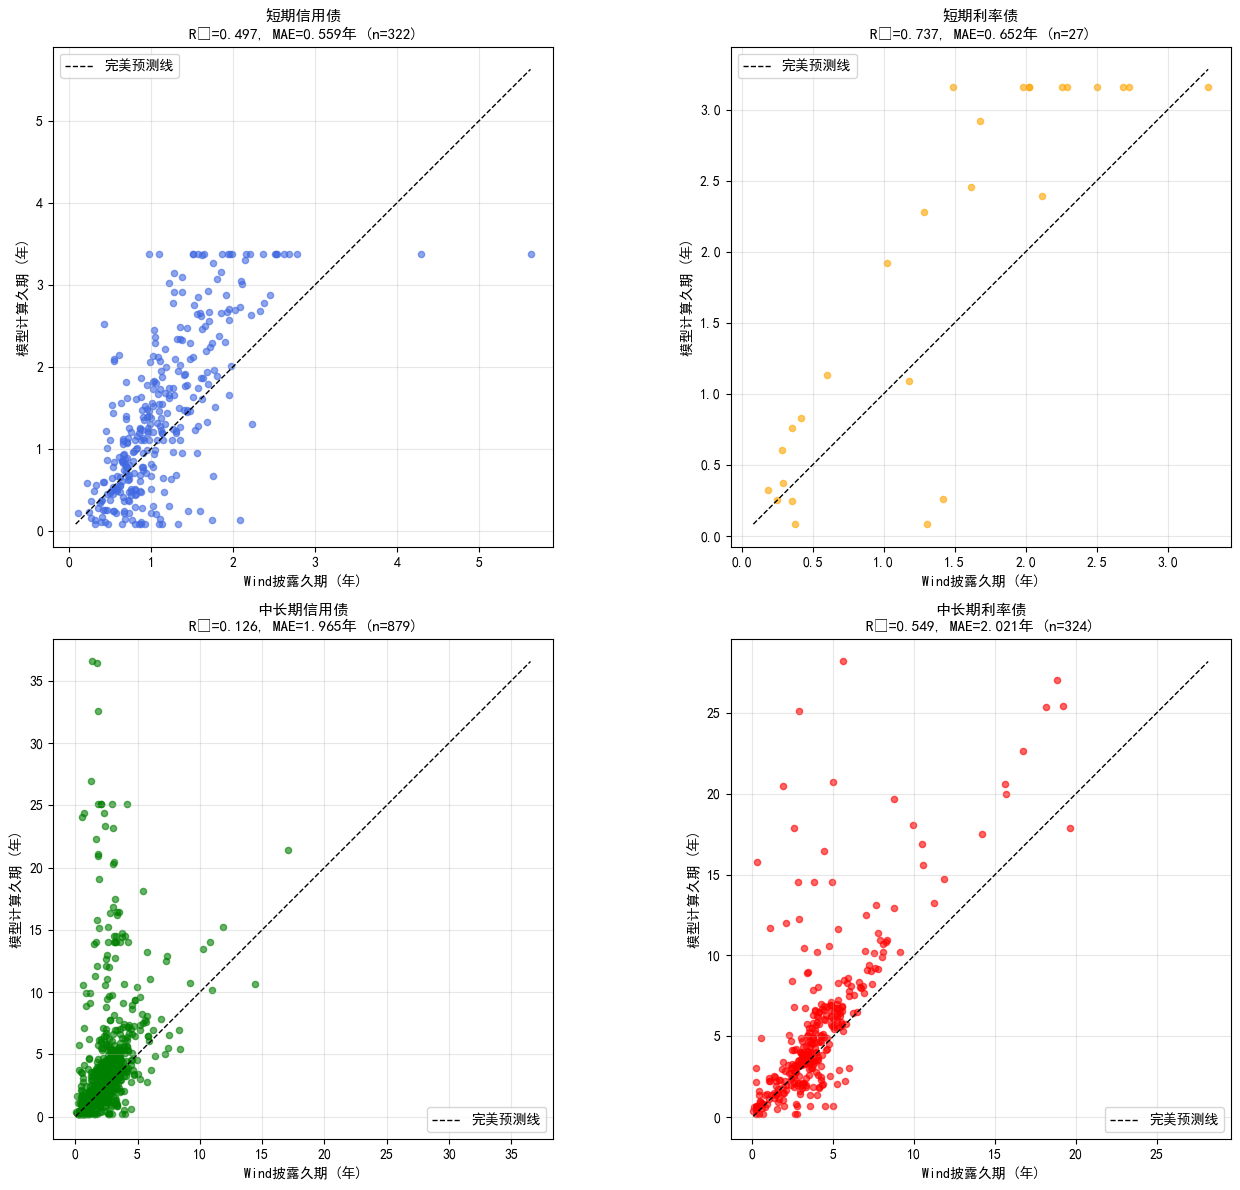

散点图已保存为: ./output/久期验证散点图.png


In [17]:
# 绘制散点图对比
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 定义类型映射
type_map = {
    ('short', 'credit'): ('短期信用债', 'royalblue'),
    ('short', 'rate'): ('短期利率债', 'orange'),
    ('medium_long', 'credit'): ('中长期信用债', 'green'),
    ('medium_long', 'rate'): ('中长期利率债', 'red')
}

for idx, ((fund_type, bond_type), (type_name, color)) in enumerate(type_map.items()):
    ax = axes[idx // 2, idx % 2]
    
    mask = (valid_df['fund_type'] == fund_type) & (valid_df['bond_type'] == bond_type)
    subset = valid_df[mask]
    
    if len(subset) > 0:
        # 散点图
        ax.scatter(subset['wind_duration'], subset['duration'], alpha=0.6, color=color, s=20)
        
        # 45度线（完美预测线）
        min_val = min(subset['wind_duration'].min(), subset['duration'].min())
        max_val = max(subset['wind_duration'].max(), subset['duration'].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1, label='完美预测线')
        
        # 计算R²
        correlation = np.corrcoef(subset['wind_duration'], subset['duration'])[0, 1]
        r_squared = correlation ** 2
        mae = subset['duration_error'].abs().mean()
        
        ax.set_xlabel('Wind披露久期 (年)', fontsize=10)
        ax.set_ylabel('模型计算久期 (年)', fontsize=10)
        ax.set_title(f'{type_name}\nR²={r_squared:.3f}, MAE={mae:.3f}年 (n={len(subset)})', fontsize=11)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('./output/久期验证散点图.png', dpi=150, bbox_inches='tight')
plt.show()
print("散点图已保存为: ./output/久期验证散点图.png")

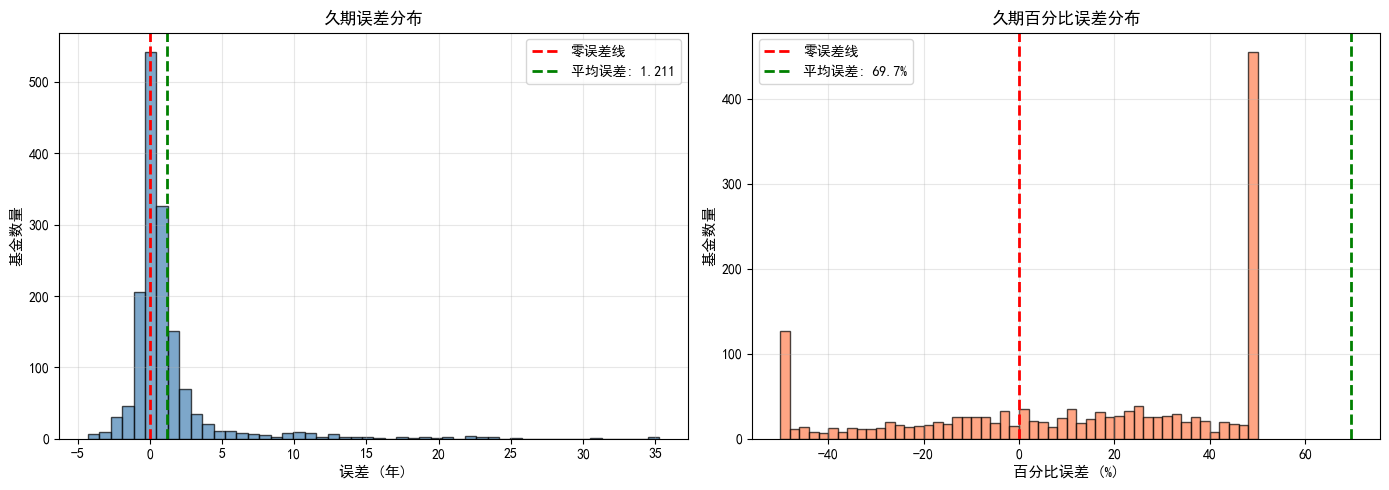

误差分布图已保存为: 误差分布图.png


In [18]:
# 误差分布直方图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 绝对误差分布
axes[0].hist(valid_df['duration_error'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', lw=2, label='零误差线')
axes[0].axvline(valid_df['duration_error'].mean(), color='green', linestyle='--', lw=2, label=f'平均误差: {valid_df["duration_error"].mean():.3f}')
axes[0].set_xlabel('误差 (年)', fontsize=11)
axes[0].set_ylabel('基金数量', fontsize=11)
axes[0].set_title('久期误差分布', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 百分比误差分布（限制在±50%以内以便观察）
pct_error_limited = valid_df['duration_pct_error'].clip(-50, 50)
axes[1].hist(pct_error_limited, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(0, color='red', linestyle='--', lw=2, label='零误差线')
axes[1].axvline(valid_df['duration_pct_error'].mean(), color='green', linestyle='--', lw=2, label=f'平均误差: {valid_df["duration_pct_error"].mean():.1f}%')
axes[1].set_xlabel('百分比误差 (%)', fontsize=11)
axes[1].set_ylabel('基金数量', fontsize=11)
axes[1].set_title('久期百分比误差分布', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./output/误差分布图.png', dpi=150, bbox_inches='tight')
plt.show()
print("误差分布图已保存为: 误差分布图.png")

In [19]:
# 找出误差最大的基金（可能有问题或需要特殊处理）
print("=== 绝对误差最大的20只基金 ===")
# 先创建绝对误差列
valid_df['duration_error_abs'] = valid_df['duration_error'].abs()
top_errors = valid_df.nlargest(20, 'duration_error_abs')[['fund_code', 'name', 'duration', 'wind_duration', 'duration_error', 'duration_pct_error', 'fund_type', 'bond_type']]
print(top_errors.to_string(index=False))

# 保存到Excel
valid_df.to_excel('./output/久期验证完整结果_20251231.xlsx', index=False)
print(f"\n完整验证结果已保存为: 久期验证完整结果_20251231.xlsx")

=== 绝对误差最大的20只基金 ===
fund_code         name  duration  wind_duration  duration_error  duration_pct_error   fund_type bond_type
012823.OF 富国安利90天滚动持有A 36.550811       1.292723       35.258088         2727.427839 medium_long    credit
007566.OF         中银宁享 36.438188       1.757815       34.680373         1972.924833 medium_long    credit
000914.OF         中加纯债 32.548691       1.807664       30.741028         1700.594328 medium_long    credit
006747.OF       东海祥利纯债 26.949016       1.244898       25.704118         2064.757285 medium_long    credit
022619.OF   永赢安和30天持有A 24.352158       0.708000       23.644158         3339.569424 medium_long    credit
002811.OF      博时裕顺纯债A 24.093986       0.495858       23.598128         4759.051724 medium_long    credit
000497.OF        财通纯债A 25.066260       1.811701       23.254559         1283.575899 medium_long    credit
001993.OF       博时裕泰纯债 25.066260       2.038903       23.027357         1129.399434 medium_long    credit
007557.OF    中加优选中高等级A 25

In [20]:
# 生成验证报告摘要
summary = []
summary.append("="*60)
summary.append("久期计算验证报告摘要")
summary.append("="*60)
summary.append(f"验证日期: 2025-12-31")
summary.append(f"总计算基金数: {len(result_df)}")
summary.append(f"有效验证数（有Wind真实久期）: {len(valid_df)}")
summary.append("")
summary.append("整体误差统计:")
summary.append(f"  - 平均绝对误差 (MAE): {valid_df['duration_error'].abs().mean():.4f} 年")
summary.append(f"  - 误差标准差: {valid_df['duration_error'].std():.4f} 年")
summary.append(f"  - 相关系数: {np.corrcoef(valid_df['wind_duration'], valid_df['duration'])[0,1]:.4f}")
summary.append(f"  - R²: {(np.corrcoef(valid_df['wind_duration'], valid_df['duration'])[0,1])**2:.4f}")
summary.append("")
summary.append("按类型统计:")

for fund_type in ['short', 'medium_long']:
    for bond_type in ['credit', 'rate']:
        mask = (valid_df['fund_type'] == fund_type) & (valid_df['bond_type'] == bond_type)
        subset = valid_df[mask]
        
        if len(subset) > 0:
            fund_type_name = '短期' if fund_type == 'short' else '中长期'
            bond_type_name = '信用债' if bond_type == 'credit' else '利率债'
            correlation = np.corrcoef(subset['wind_duration'], subset['duration'])[0,1]
            
            summary.append(f"  {fund_type_name}{bond_type_name} (n={len(subset)}):")
            summary.append(f"    MAE: {subset['duration_error'].abs().mean():.4f}年, R²: {correlation**2:.4f}")

summary.append("="*60)

# 打印报告
print("\n".join(summary))

# 保存报告
with open('./output/验证报告.txt', 'w', encoding='utf-8') as f:
    f.write("\n".join(summary))
print("\n验证报告已保存为: ./output/验证报告.txt")

久期计算验证报告摘要
验证日期: 2025-12-31
总计算基金数: 1563
有效验证数（有Wind真实久期）: 1552

整体误差统计:
  - 平均绝对误差 (MAE): 1.6621 年
  - 误差标准差: 3.5939 年
  - 相关系数: 0.5677
  - R²: 0.3223

按类型统计:
  短期信用债 (n=322):
    MAE: 0.5586年, R²: 0.4972
  短期利率债 (n=27):
    MAE: 0.6522年, R²: 0.7367
  中长期信用债 (n=879):
    MAE: 1.9651年, R²: 0.1260
  中长期利率债 (n=324):
    MAE: 2.0207年, R²: 0.5488

验证报告已保存为: ./output/验证报告.txt
